<a href="https://colab.research.google.com/github/Saichand-design/Fake_News_Detection_Using_NLP/blob/main/IBM_HR_Analytics_Decision_Tree_%26_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np


In [2]:

df =pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [3]:
print("Shape:", df.shape)

Shape: (1470, 35)


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [7]:
Missing Values
print(df.isnull().sum().sum(), 'missing values found')

0 missing values found


In [9]:
# Drop Useless Columns
df = df.drop(['EmployeeCount','StandardHours','Over18','EmployeeNumber'],axis=1)
print('Shape after drop:', df.shape)

Shape after drop: (1470, 31)


EDA


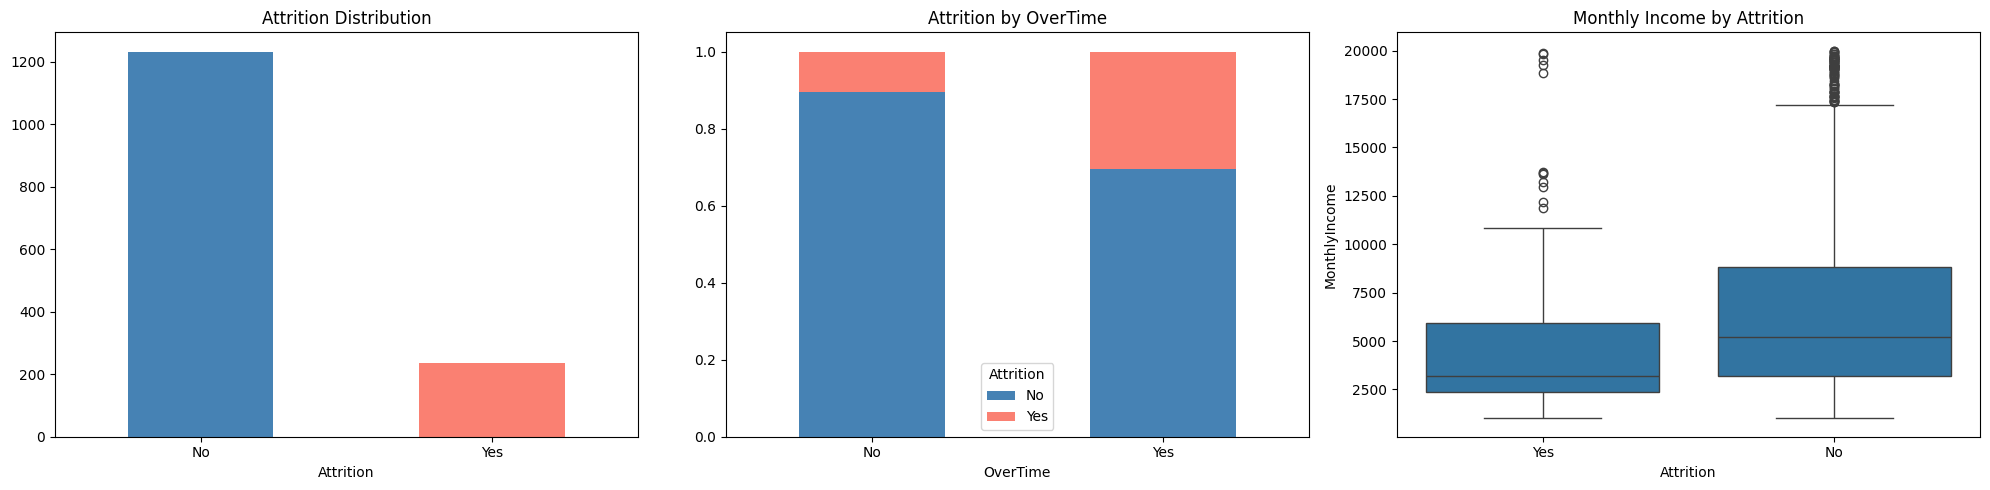

In [24]:


fig,axes = plt.subplots(nrows=1,ncols=2,figsize=(15,5))

df['Attrition'].value_counts().plot(kind='bar',ax=axes[0],color=['steelblue','salmon'])
axes[0].set_title('Attrition Distribution')
axes[0].tick_params(axis='x', rotation=0)

pd.crosstab(df['OverTime'],df['Attrition'],normalize='index').plot(kind='bar',stacked=True,ax=axes[1],color=['steelblue','salmon'])
axes[1].set_title('Attrition by OverTime')
axes[1].tick_params(axis='x', rotation=0)

sns.boxplot(x='Attrition',y='MonthlyIncome',data=df,ax=axes[2])
axes[2].set_title('Age by Attrition')

plt.tight_layout()
plt.show()
#f['Attrition'].value_counts().plot(kind='pie',ax=axes[1].set_title('Attrition Distribution'))


#





In [25]:
# Encoding
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
df['OverTime'] = df['OverTime'].map({'Yes':1, 'No':0})

df['Attrition'] = df['Attrition'].map({'Yes':1,"No":0})



In [26]:
# Split X and y
cat_cols = ['BusinessTravel','Department','EducationField','JobRole','MaritalStatus']

#num_cols = ['Age','DailyRate','DistanceFromHome','HourlyRate','MonthlyIncome','NumCompaniesWorked','PercentSalary']


X = df.drop('Attrition',axis=1)
y = df['Attrition']


In [30]:
# Class Balance Check
print(y.value_counts())
print()
print(y.value_counts(normalize=True)*100)


Attrition
0    1233
1     237
Name: count, dtype: int64

Attrition
0    83.877551
1    16.122449
Name: proportion, dtype: float64


In [33]:
# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify=y, random_state=42)

print('Train:', X_train.shape )
print('Test:', X_test.shape)

print('\nTrain balance(%):')
print(y_train.value_counts(normalize=True)*100)
print('\nTest balance(%):')
print(y_test.value_counts(normalize=True)*100)

Train: (1176, 30)
Test: (294, 30)

Train balance(%):
Attrition
0    83.843537
1    16.156463
Name: proportion, dtype: float64

Test balance(%):
Attrition
0    84.013605
1    15.986395
Name: proportion, dtype: float64


One Hot Encoding


In [36]:
encoder = OneHotEncoder(drop='frist', sparse_output=False)
X_train_encoded = encoder.fit_transform(X_train[cat_cols])
X_test_encoded = encoder.transform(X_test[cat_cols])

In [37]:
ohe_cols = encoder.get_feature_names_out(cat_cols)

train_enc_df = pd.DataFrame(X_train_encoded, columns=ohe_cols, index=X_train.index)
test_enc_df = pd.DataFrame(X_test_encoded, columns=ohe_cols, index=X_test.index)

In [38]:
X_train = pd.concat([X_train.drop(cat_cols, axis=1), train_enc_df], axis=1)
X_test = pd.concat([X_test.drop(cat_cols, axis=1), test_enc_df], axis=1)

In [41]:
print('X_train Shape:', X_train.shape)
print('X_test Shape:' ,X_test.shape)

X_train Shape: (1176, 44)
X_test Shape: (294, 44)


In [43]:
# Train & Evaluate

def evaluate_model(model, X_test, y_test,name):
  y_pred = model.predict(X_test)
  print(f'---{name}----')
  print('Accuracy:',round(accuracy_score(y_test, y_pred),4))
  print(confusion_matrix(y_test, y_pred))
  print(classification_report(y_test, y_pred))


In [44]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
evaluate_model(dt, X_test, y_test,'Decision Tree')

---Decision Tree----
Accuracy: 0.7585
[[206  41]
 [ 30  17]]
              precision    recall  f1-score   support

           0       0.87      0.83      0.85       247
           1       0.29      0.36      0.32        47

    accuracy                           0.76       294
   macro avg       0.58      0.60      0.59       294
weighted avg       0.78      0.76      0.77       294



In [45]:
# Random Forest

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
evaluate_model(rf, X_test, y_test,'Random Forest')

---Random Forest----
Accuracy: 0.8333
[[240   7]
 [ 42   5]]
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.42      0.11      0.17        47

    accuracy                           0.83       294
   macro avg       0.63      0.54      0.54       294
weighted avg       0.78      0.83      0.79       294



In [46]:
# Random Forest + Smote

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print('Class distribution after SMOTE:')
print(y_train_sm.value_counts())
print()
rf_sm = RandomForestClassifier(random_state=42)
rf_sm.fit(X_train_sm, y_train_sm)
evaluate_model(rf_sm, X_test, y_test,'Random Forest + Smote')

Class distribution after SMOTE:
Attrition
0    986
1    986
Name: count, dtype: int64

---Random Forest + Smote----
Accuracy: 0.8435
[[238   9]
 [ 37  10]]
              precision    recall  f1-score   support

           0       0.87      0.96      0.91       247
           1       0.53      0.21      0.30        47

    accuracy                           0.84       294
   macro avg       0.70      0.59      0.61       294
weighted avg       0.81      0.84      0.81       294



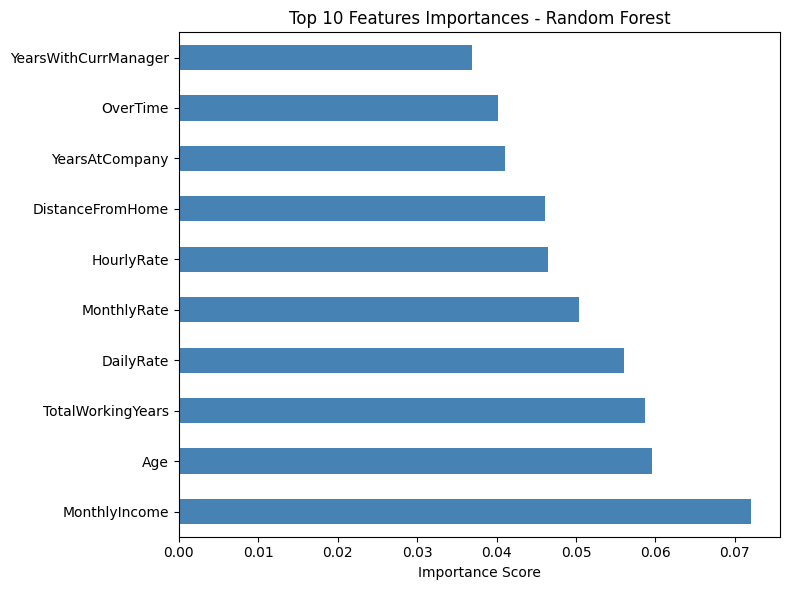

In [48]:
# Featue Importance

feature_imp = pd.Series(rf.feature_importances_, index=X_train.columns)
feature_imp.nlargest(10).plot(kind='barh',figsize=(8,6),color='steelblue')
plt.title('Top 10 Features Importances - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()